# Retinal Disease Screening — Model Notebook (Initial MVP)

**Capstone Project:** An Offline-First Mobile Application for Multi-Disease Retinal Screening in Primary Health Centers
**Author:** Michael Kimani

This notebook implements the transfer-learning approach described in Section 3.3 of the
research proposal: a pretrained MobileNetV2 backbone, fine-tuned on retinal fundus images,
suitable for later on-device (TensorFlow Lite) deployment.

**Scope of this initial MVP:** to keep this first demo tractable within the assignment
timeline, this notebook builds and trains a working diabetic retinopathy (DR) classifier on
the combined EyePACS + APTOS + Messidor dataset (`ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy`) end-to-end (data loading -> visualization -> model -> training ->
evaluation). Extending this same pipeline to glaucoma and cataract classification on
ODIR-5K, and combining all three into one multi-head model, is the planned next iteration
for the Final Capstone Implementation.

## 1. Setup

In [2]:
!pip install -q tensorflow scikit-learn seaborn --upgrade

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 103.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 9.5 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
google-cloud-bigtable 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.

## 2. Load the dataset

**Dataset:** [`ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy`](https://www.kaggle.com/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy) on Kaggle -- a combined, resized (600x600) collection built from EyePACS, APTOS 2019, APTOS Gaussian-Filtered, and Messidor-2, using the same 5-step ICDR grading scale (0 = No DR ... 4 = Proliferative DR) as the original APTOS notebook, so it binarizes the same way.

**Important caveats for this dataset (worth naming explicitly in the capstone writeup):**
- The curator reports the redistribution applies augmentation that expands the collection by roughly 55% over the four source datasets combined. At least one published paper that used this exact dataset found it necessary to manually deduplicate thousands of near-duplicate/augmented rows before treating a train/val/test split as leakage-free. We therefore do **not** trust any train/val/test folders this dataset ships with at face value, and instead group-split ourselves below so that augmented copies of the same source image can't land on both sides of a split.
- The underlying EyePACS and APTOS competition data are both licensed for non-commercial/academic use with redistribution restrictions from their original hosts; this is a third-party redistribution. Fine for coursework, but worth a one-line acknowledgement in the capstone report's data-sources section.

**Step 1 -- download and inspect the real folder layout first**, since Kaggle dataset internals vary by version and we don't want to guess wrong and silently load the wrong files.

In [3]:
import kagglehub
import os

# Download latest version
DATASET_PATH = "/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy"
print("Path to dataset files:", DATASET_PATH)

# Inspect the folder structure (first 3 levels) so we know exactly how to load it,
# rather than assuming a structure and hitting FileNotFoundError later.
for root, dirs, files in os.walk(DATASET_PATH):
    depth = root[len(DATASET_PATH):].count(os.sep)
    if depth <= 2:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root) or root}/  ({len(files)} files, {len(dirs)} subdirs)")
        for f in sorted(files)[:3]:
            print(f"{indent}  - {f}")


Path to dataset files: /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy
eyepacs-aptos-messidor-diabetic-retinopathy/  (0 files, 2 subdirs)
  dr_unified_v2/  (0 files, 1 subdirs)
    dr_unified_v2/  (0 files, 3 subdirs)
  augmented_resized_V2/  (0 files, 3 subdirs)
    val/  (0 files, 5 subdirs)
    test/  (0 files, 5 subdirs)
    train/  (0 files, 5 subdirs)


In [4]:
import glob
import re
import pandas as pd

IMG_EXTS = (".png", ".jpg", ".jpeg")

csv_files = glob.glob(os.path.join(DATASET_PATH, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

records = []

if csv_files:
    # CSV-driven layout, e.g. an id/diagnosis column per row (same shape as APTOS's train_1.csv)
    for csv_path in csv_files:
        sub = pd.read_csv(csv_path)
        base_dir = os.path.dirname(csv_path)
        id_col = next((c for c in sub.columns if "id" in c.lower() or "image" in c.lower() or "file" in c.lower()), None)
        label_col = next((c for c in sub.columns if any(k in c.lower() for k in ("diagnosis", "label", "grade", "level"))), None)
        if id_col is None or label_col is None:
            print(f"Skipping {csv_path}: couldn't identify id/label columns ({list(sub.columns)})")
            continue
        for _, r in sub.iterrows():
            stem = str(r[id_col])
            candidates = [stem] if stem.lower().endswith(IMG_EXTS) else [stem + ext for ext in IMG_EXTS]
            fpath = None
            for cand in candidates:
                hits = glob.glob(os.path.join(base_dir, "**", cand), recursive=True)
                if hits:
                    fpath = hits[0]
                    break
            if fpath:
                records.append({"filepath": fpath, "diagnosis": int(r[label_col])})
else:
    # Folder-per-class layout, e.g. .../train/0/*.png .../train/4/*.png
    class_dirs = [d for d in glob.glob(os.path.join(DATASET_PATH, "**", "*"), recursive=True)
                  if os.path.isdir(d) and os.path.basename(d) in {"0", "1", "2", "3", "4"}]
    for cd in class_dirs:
        label = int(os.path.basename(cd))
        for fpath in glob.glob(os.path.join(cd, "*")):
            if fpath.lower().endswith(IMG_EXTS):
                records.append({"filepath": fpath, "diagnosis": label})

df = pd.DataFrame(records)
assert len(df) > 0, "No images matched -- check the printed folder structure above and adjust the loader."

df["label"] = (df["diagnosis"] > 0).astype(int)  # 0 = No DR, 1 = DR present (same binarization as before)

print(f"Total samples found: {len(df)}")
df.head()


CSV files found: []
Total samples found: 236170


,filepath,diagnosis,label
0,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,2,1
1,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,2,1
2,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,2,1
3,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,2,1
4,/kaggle/input/datasets/ascanipek/eyepacs-aptos...,2,1


## 3. Data visualization and engineering

/tmp/ipykernel_58/2021926281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, ax=axes[0], palette="viridis")
/tmp/ipykernel_58/2021926281.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, ax=axes[1], palette="pastel")
/tmp/ipykernel_58/2021926281.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No DR", "DR present"])


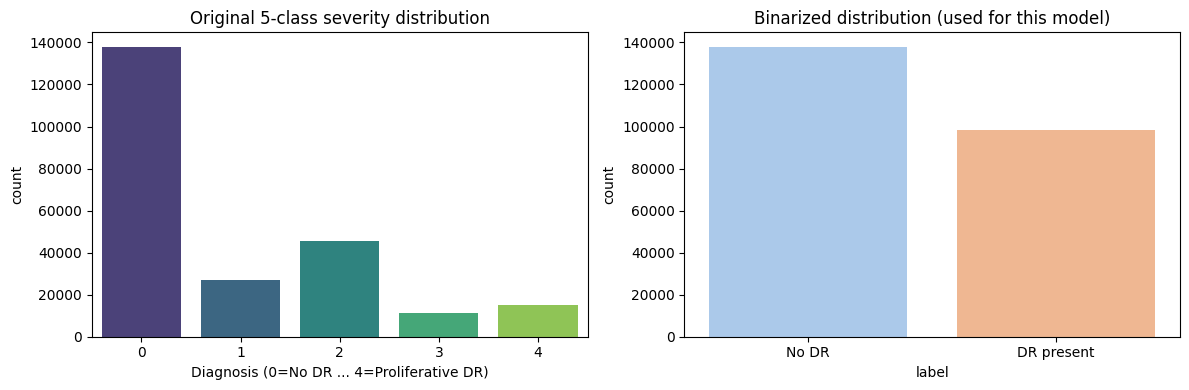

label
0    0.583927
1    0.416073
Name: proportion, dtype: float64


In [5]:
# --- Class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="diagnosis", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Original 5-class severity distribution")
axes[0].set_xlabel("Diagnosis (0=No DR ... 4=Proliferative DR)")

sns.countplot(x="label", data=df, ax=axes[1], palette="pastel")
axes[1].set_title("Binarized distribution (used for this model)")
axes[1].set_xticklabels(["No DR", "DR present"])

plt.tight_layout()
plt.show()

print(df["label"].value_counts(normalize=True))

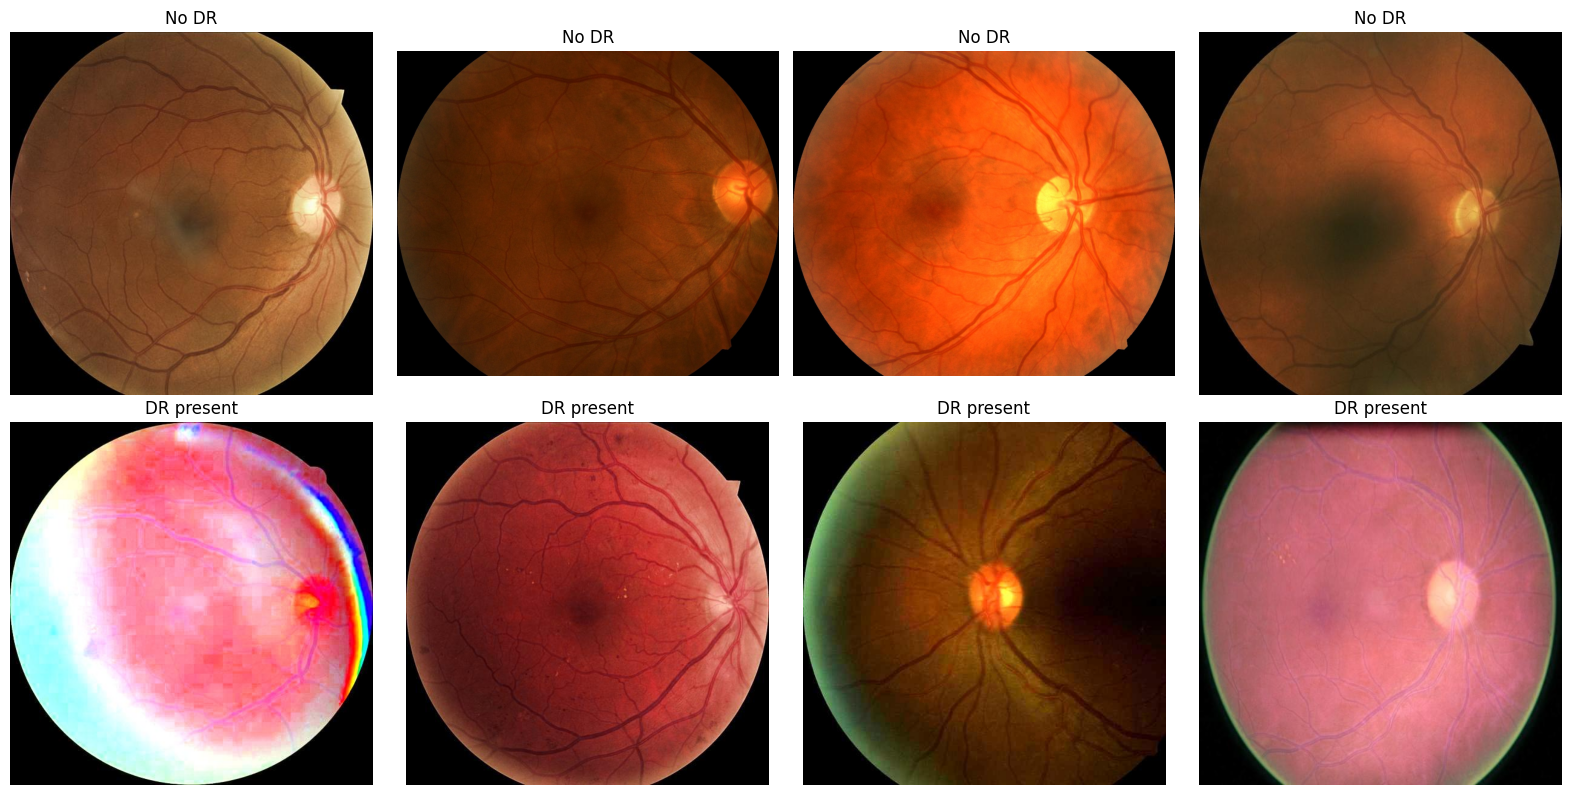

In [6]:
# --- Sample images per class ---
class_names = {0: "No DR", 1: "DR present"}
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, label_val in enumerate([0, 1]):
    samples = df[df["label"] == label_val].sample(4, random_state=SEED)
    for col, (_, r) in enumerate(samples.iterrows()):
        img = Image.open(r["filepath"])
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_names[label_val])
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 4. Train/validation split and data generators

Because this dataset's own augmentation can leave near-duplicate copies of the same source photo scattered across the data, a plain random split risks putting one copy in `train` and another copy of the *same underlying image* in `val` -- the model would partly be validated on images it has effectively already seen, inflating validation metrics. We group-split on a recovered "base id" (the filename with any trailing augmentation suffix stripped) so every variant of one source image stays on the same side of the split, using `StratifiedGroupKFold` to keep both that guarantee and the class balance.

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

from sklearn.model_selection import StratifiedGroupKFold

def base_id(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    # Strip common augmentation-suffix patterns. INSPECT df['filepath'] samples above and adjust
    # this regex if this dataset's real augmented filenames follow a different convention.
    return re.sub(r'(_aug\d*|_flip\w*|_rot(ate)?\d*|_crop\d*|_v\d+|_\d+)$', '', stem, flags=re.IGNORECASE)

df["base_id"] = df["filepath"].apply(base_id)
n_total, n_unique = len(df), df["base_id"].nunique()
print(f"{n_total} images -> {n_unique} unique base ids "
      f"({'looks already de-duplicated' if n_unique > 0.95*n_total else 'duplicates/augmented copies detected -- group split is doing real work here'})")

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(df, y=df["label"], groups=df["base_id"]))
train_df, val_df = df.iloc[train_idx].copy(), df.iloc[val_idx].copy()
print(f"Train: {len(train_df)}  |  Validation: {len(val_df)}")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_df["label_str"] = train_df["label"].astype(str)
val_df["label_str"] = val_df["label"].astype(str)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label_str",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", seed=SEED,
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label_str",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", shuffle=False, seed=SEED,
)

# Class weights to address the imbalance visualized above
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=train_df["label"]
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


236170 images -> 236170 unique base ids (looks already de-duplicated)
Train: 188936  |  Validation: 47234
Found 188936 validated image filenames belonging to 2 classes.
Found 47234 validated image filenames belonging to 2 classes.
Class weights: {0: np.float64(0.8562701110355767), 1: np.float64(1.2017147727417283)}


## 5. Model architecture

Matches the proposal's ML Solution (Section 3.3): a **MobileNetV2** backbone pretrained on
ImageNet, with its convolutional base frozen and a small trainable classification head added
on top. MobileNetV2 is chosen specifically for its suitability for later on-device inference
via TensorFlow Lite, per the mobile deployment plan.

In [8]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False  # freeze pretrained weights for this initial fine-tune

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Training

In [9]:
EPOCHS = 8  # kept modest for this initial MVP; extend for the final implementation

early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Epoch 1/8


E0000 00:00:1790498076.481724     147 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  43/5905 ━━━━━━━━━━━━━━━━━━━━ 1:00:40 621ms/step - accuracy: 0.5164 - loss: 0.8164 - precision: 0.4044 - recall: 0.4456

E0000 00:00:1790498119.191812     147 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5905/5905 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.6840 - loss: 0.5927 - precision: 0.6202 - recall: 0.6125

E0000 00:00:1790503251.177124     146 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5905/5905 ━━━━━━━━━━━━━━━━━━━━ 5204s 877ms/step - accuracy: 0.7153 - loss: 0.5573 - precision: 0.6650 - recall: 0.6363 - val_accuracy: 0.7469 - val_loss: 0.5136 - val_precision: 0.9213 - val_recall: 0.4283
Epoch 2/8
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 3625s 614ms/step - accuracy: 0.7481 - loss: 0.5178 - precision: 0.7167 - recall: 0.6524 - val_accuracy: 0.7670 - val_loss: 0.4890 - val_precision: 0.9103 - val_recall: 0.4881
Epoch 3/8
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 3651s 618ms/step - accuracy: 0.7579 - loss: 0.5054 - precision: 0.7330 - recall: 0.6578 - val_accuracy: 0.7686 - val_loss: 0.4860 - val_precision: 0.9163 - val_recall: 0.4886
Epoch 4/8
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 3549s 601ms/step - accuracy: 0.7645 - loss: 0.4958 - precision: 0.7431 - recall: 0.6632 - val_accuracy: 0.7661 - val_loss: 0.4852 - val_precision: 0.9322 - val_recall: 0.4723
Epoch 5/8
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 3527s 597ms/step - accuracy: 0.7691 - loss: 0.4890 - precision: 0.7513 - recall: 0.6652 - val_accuracy: 0

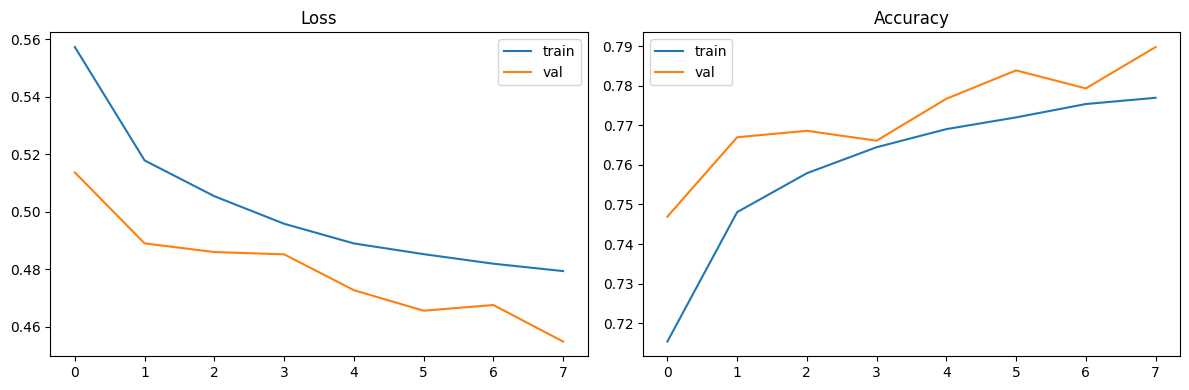

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Evaluation — initial performance metrics

In [11]:
val_gen.reset()
y_true = val_gen.classes
y_pred_prob = model.predict(val_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (sensitivity): {rec:.3f}")
print(f"F1 score:  {f1:.3f}")
print()
print(classification_report(y_true, y_pred, target_names=["No DR", "DR present"]))

1477/1477 ━━━━━━━━━━━━━━━━━━━━ 354s 236ms/step
Accuracy:  0.790
Precision: 0.920
Recall (sensitivity): 0.542
F1 score:  0.682

              precision    recall  f1-score   support

       No DR       0.75      0.97      0.84     27581
  DR present       0.92      0.54      0.68     19653

    accuracy                           0.79     47234
   macro avg       0.83      0.75      0.76     47234
weighted avg       0.82      0.79      0.78     47234



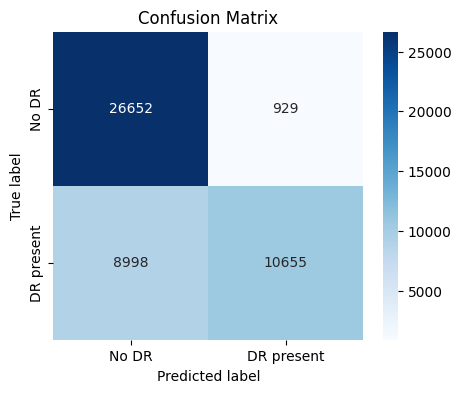

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No DR", "DR present"],
            yticklabels=["No DR", "DR present"])
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix")
plt.show()

**Reading these results against the proposal's Target Metrics (Section 3.3):** the proposal
sets a minimum target of 85% sensitivity for diabetic retinopathy classification, prioritized
over specificity since a missed positive case carries greater clinical risk than a false
positive. Recall above is the sensitivity figure to compare directly against that target. As
an initial MVP with only a few training epochs and a frozen backbone, this run is expected to
sit below the final target; the Final Capstone Implementation will extend training (unfreezing
deeper backbone layers, more epochs, and threshold tuning) to close that gap.

## 8. Save model for deployment

In [13]:
model.save("dr_screening_model.h5")

# Convert to TensorFlow Lite for on-device mobile inference, per the proposal's
# System Architecture (on-device inference via TensorFlow Lite).
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("dr_screening_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved dr_screening_model.h5 and dr_screening_model.tflite")

INFO:tensorflow:Assets written to: /tmp/tmpls0l2ay0/assets


INFO:tensorflow:Assets written to: /tmp/tmpls0l2ay0/assets


Saved artifact at '/tmp/tmpls0l2ay0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135308380133648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380133072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380133264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380135952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380134800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380136528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380134992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380137104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380136720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308380134608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13530838013537

## Next steps (Final Capstone Implementation)

- Integrate ODIR-5K for glaucoma and cataract classification, extending this to a
  multi-label or multi-head model covering all three target conditions
- Unfreeze and fine-tune deeper MobileNetV2 layers for improved sensitivity
- Threshold tuning to explicitly hit the 85% sensitivity / 80% specificity targets
- Wire the saved `.tflite` model into the Streamlit MVP interface for live prediction demo